In [1]:
from phenotype_decoders.multi_decoder import multi_decoder
import matplotlib.pyplot as plt

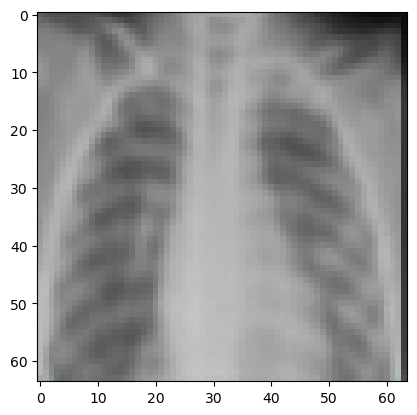

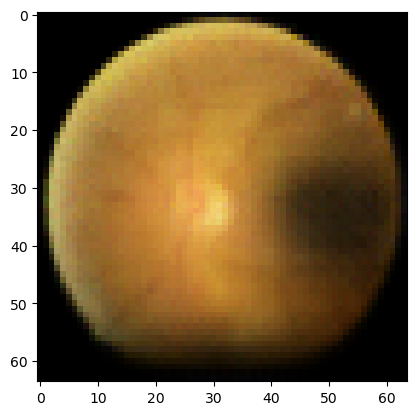

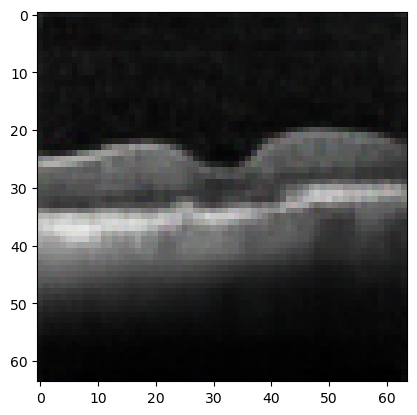

In [2]:
state = (0.0,0.1,0.9)
images = multi_decoder(state)
for image in images:
    plt.figure()
    plt.imshow(image)

In [6]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from phenotype_decoders.base_decoder import decode_state, load_decoder, parse_state, state_label

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_dir = Path("phenotype_decoders/checkpoints")
output_dir = Path("phenotype_decoders/observation_data/generated_observations")
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
state = (0.0,0.9,0.1)
sn = "010"

decoders = {"pneumonia":"pneumonia_decoder.pt", "fundus":"fundus_decoder.pt", "oct":"oct_decoder.pt"}
for name, dec in decoders.items():
    decoder = load_decoder(dec, checkpoint_dir, device)
    image = decode_state(decoder, state, device, round_to_training_state=False)
    plt.figure()
    plt.imshow(image)
    output_path = output_dir / f"{name}-{sn}.png"
    image.save(output_path)
    print(f"Saved {output_path}")
